<a href="https://colab.research.google.com/github/sorel07/think_python/blob/main/chapters/chap04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Puedes comprar versiones impresas y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');
download('https://github.com/ramalho/jupyturtle/releases/download/2024-03/jupyturtle.py');

Downloaded thinkpython.py
Downloaded diagram.py
Downloaded jupyturtle.py


In [2]:
import thinkpython

%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

# Funciones e interfaces

Este capítulo introduce un módulo llamado `jupyturtle`, que te permite crear dibujos sencillos dando instrucciones a una turtle imaginaria.
Usaremos este módulo para escribir funciones que dibujan cuadrados, polígonos y círculos, y para demostrar el **diseño de interfaces**, que es una forma de diseñar funciones que trabajan juntas.

## El módulo jupyturtle

Para usar el módulo `jupyturtle`, podemos importarlo así.

In [3]:
import jupyturtle

Ahora podemos usar las funciones definidas en el módulo, como `make_turtle` y `forward`.

In [4]:
jupyturtle.make_turtle()
jupyturtle.forward(100)

`make_turtle` crea un **canvas**, que es un espacio en la pantalla donde podemos dibujar, y una turtle, que se representa con un caparazón circular y una cabeza triangular.
El círculo muestra la ubicación de la turtle y el triángulo indica la dirección hacia la que mira.

`forward` mueve la turtle una distancia dada en la dirección hacia la que mira, dibujando un segmento de línea por el camino.
La distancia está en unidades arbitrarias: el tamaño real depende de la pantalla de tu ordenador.

Usaremos muchas veces funciones definidas en el módulo `jupyturtle`, así que estaría bien no tener que escribir el nombre del módulo cada vez.
Eso es posible si importamos el módulo así.

In [5]:
from jupyturtle import make_turtle, forward

Esta versión de la sentencia `import` importa `make_turtle` y `forward` desde el módulo `jupyturtle`, de modo que podemos llamarlas así.

In [6]:
make_turtle()
forward(100)

`jupyturtle` proporciona otras dos funciones que usaremos, llamadas `left` y `right`.
Las importaremos así.

In [8]:
from jupyturtle import left, right

`left` hace que la turtle gire a la izquierda. Recibe un argumento, que es el ángulo del giro en grados.
Por ejemplo, podemos hacer un giro a la izquierda de 90 grados así.

In [9]:
make_turtle()
forward(50)
left(90)
forward(50)

Este programa mueve la turtle hacia el este y luego hacia el norte, dejando dos segmentos de línea detrás.
Antes de continuar, prueba si puedes modificar el programa anterior para hacer un cuadrado.

## Hacer un cuadrado

Aquí tienes una forma de hacer un cuadrado.

In [10]:
make_turtle()

forward(50)
left(90)

forward(50)
left(90)

forward(50)
left(90)

forward(50)
left(90)

Como este programa repite el mismo par de líneas cuatro veces, podemos hacer lo mismo de forma más concisa con un bucle `for`.

In [11]:
make_turtle()
for i in range(4):
    forward(50)
    left(90)

## Encapsulación y generalización

Tomemos el código para dibujar cuadrados de la sección anterior y pongámoslo en una función llamada `square`.

In [36]:
def square():
    for i in range(4):
        forward(50)
        left(90)

Ahora podemos llamar a la función así.

In [37]:
make_turtle()
square()

Envolver un fragmento de código en una función se llama **encapsulación**.
Uno de los beneficios de la encapsulación es que le da un nombre al código, que sirve como una especie de documentación. ¡Otra ventaja es que, si reutilizas el código, es más conciso llamar a una función dos veces que copiar y pegar el cuerpo!

En la versión actual, el tamaño del cuadrado siempre es `50`.
Si queremos dibujar cuadrados de distintos tamaños, podemos tomar la longitud de los lados como parámetro.

In [14]:
def square(length):
    for i in range(4):
        forward(length)
        left(90)

Ahora podemos dibujar cuadrados de distintos tamaños.

In [15]:
make_turtle()
square(30)
square(60)

Añadir un parámetro a una función se llama **generalización** porque hace que la función sea más general: con la versión anterior, el cuadrado siempre tiene el mismo tamaño; con esta versión puede tener cualquier tamaño.

Si añadimos otro parámetro, podemos hacerla aún más general.
La siguiente función dibuja polígonos regulares con un número dado de lados.

In [16]:
def polygon(n, length):
    angle = 360 / n
    for i in range(n):
        forward(length)
        left(angle)

En un polígono regular con `n` lados, el ángulo entre lados adyacentes es de `360 / n` grados.

El siguiente ejemplo dibuja un polígono de `7` lados con longitud de lado `30`.

In [17]:
make_turtle()
polygon(7, 30)

Cuando una función tiene más de unos pocos argumentos numéricos, es fácil olvidar qué son o en qué orden deberían ir.
Puede ser una buena idea incluir los nombres de los parámetros en la lista de argumentos.

In [18]:
make_turtle()
polygon(n=7, length=30)

A veces se llaman "argumentos con nombre" porque incluyen los nombres de los parámetros.
Pero en Python se llaman más a menudo **argumentos de palabra clave** (no deben confundirse con las palabras clave de Python como `for` y `def`).

Este uso del operador de asignación, `=`, sirve como recordatorio de cómo funcionan los argumentos y los parámetros: cuando llamas a una función, los argumentos se asignan a los parámetros.

## Aproximar un círculo

Ahora supongamos que queremos dibujar un círculo.
Podemos hacerlo, aproximadamente, dibujando un polígono con un gran número de lados, de modo que cada lado sea lo bastante pequeño como para que cueste verlo.
Aquí tienes una función que usa `polygon` para dibujar un polígono de `30` lados que aproxima un círculo.

In [20]:
import math

def circle(radius):
    circumference = 2 * math.pi * radius
    n = 30
    length = circumference / n
    polygon(n, length)

`circle` recibe el radio del círculo como parámetro.
Calcula `circumference`, que es la circunferencia de un círculo con el radio dado.
`n` es el número de lados, así que `circumference / n` es la longitud de cada lado.

Esta función podría tardar mucho en ejecutarse.
Podemos acelerarla llamando a `make_turtle` con un argumento de palabra clave llamado `delay` que establece el tiempo, en segundos, que la turtle espera después de cada paso.
El valor predeterminado es `0.2` segundos; si lo establecemos en `0.02`, se ejecuta unas 10 veces más rápido.

In [22]:
make_turtle(delay=0.02)
circle(30)

Una limitación de esta solución es que `n` es una constante, lo que significa
que para círculos muy grandes los lados son demasiado largos, y para círculos pequeños
perdemos tiempo dibujando lados muy cortos.
Una opción es generalizar la función tomando `n` como parámetro.
Pero mantengámoslo sencillo por ahora.

## Refactorización

Ahora escribamos una versión más general de `circle`, llamada `arc`, que recibe un segundo parámetro, `angle`, y dibuja un arco de un círculo que abarca el ángulo dado.
Por ejemplo, si `angle` es `360` grados, dibuja un círculo completo. Si `angle` es `180` grados, dibuja un semicírculo.

Para escribir `circle`, pudimos reutilizar `polygon`, porque un polígono con muchos lados es una buena aproximación de un círculo.
Pero no podemos usar `polygon` para escribir `arc`.

En su lugar, crearemos una versión más general de `polygon`, llamada `polyline`.

In [23]:
def polyline(n, length, angle):
    for i in range(n):
        forward(length)
        left(angle)

`polyline` recibe como parámetros el número de segmentos de línea que debe dibujar, `n`, la longitud de los segmentos, `length`, y el ángulo entre ellos, `angle`.

Ahora podemos reescribir `polygon` para que use `polyline`.

In [24]:
def polygon(n, length):
    angle = 360.0 / n
    polyline(n, length, angle)

Y podemos usar `polyline` para escribir `arc`.

In [25]:
def arc(radius, angle):
    arc_length = 2 * math.pi * radius * angle / 360
    n = 30
    length = arc_length / n
    step_angle = angle / n
    polyline(n, length, step_angle)

`arc` es similar a `circle`, salvo que calcula `arc_length`, que es una fracción de la circunferencia de un círculo.

Por último, podemos reescribir `circle` para que use `arc`.

In [26]:
def circle(radius):
    arc(radius,  360)

Para comprobar que estas funciones funcionan como esperamos, las usaremos para dibujar algo parecido a un caracol.
Con `delay=0`, la turtle va lo más rápido posible.

In [28]:
make_turtle(delay=0)
polygon(n=20, length=9)
arc(radius=70, angle=70)
circle(radius=10)

En este ejemplo, empezamos con código que funcionaba y lo reorganizamos con funciones diferentes.
Los cambios como este, que mejoran el código sin cambiar su comportamiento, se llaman **refactorización**.

Si lo hubiéramos planeado con antelación, quizá habríamos escrito `polyline` primero y evitado la refactorización, pero a menudo no sabes lo suficiente al principio de un proyecto para diseñar todas las funciones.
Una vez que empiezas a programar, entiendes mejor el problema.
A veces la refactorización es una señal de que has aprendido algo.

## Diagrama de pila

Cuando llamamos a `circle`, llama a `arc`, que llama a `polyline`.
Podemos usar un diagrama de pila para mostrar esta secuencia de llamadas a funciones y los parámetros de cada una.

In [29]:
from diagram import make_binding, make_frame, Frame, Stack

frame1 = make_frame(dict(radius=30), name='circle', loc='left')

frame2 = make_frame(dict(radius=30, angle=360), name='arc', loc='left', dx=1.1)

frame3 = make_frame(dict(n=60, length=3.04, angle=5.8),
                    name='polyline', loc='left', dx=1.1, offsetx=-0.27)

stack = Stack([frame1, frame2, frame3], dy=-0.4)

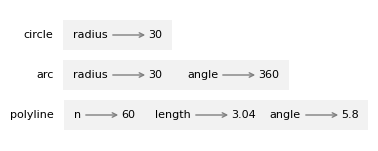

In [30]:
from diagram import diagram, adjust

width, height, x, y = [3.58, 1.31, 0.98, 1.06]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
#adjust(x, y, bbox)

Observa que el valor de `angle` en `polyline` es diferente del valor de `angle` en `arc`.
Los parámetros son locales, lo que significa que puedes usar el mismo nombre de parámetro en funciones diferentes; es una variable distinta en cada función y puede referirse a un valor diferente.

## Un plan de desarrollo

Un **plan de desarrollo** es un proceso para escribir programas.
El proceso que usamos en este capítulo es "encapsulación y generalización".
Los pasos de este proceso son:

1.  Empieza escribiendo un programa pequeño sin definiciones de funciones.

2.  Una vez que consigas que el programa funcione, identifica una parte coherente,
    encapsula esa parte en una función y dale un nombre.

3.  Generaliza la función añadiendo los parámetros adecuados.

4.  Repite los pasos 1 a 3 hasta que tengas un conjunto de funciones que funcionen.

5.  Busca oportunidades para mejorar el programa mediante refactorización. Por
    ejemplo, si tienes código similar en varios lugares, considera
    factorizarlo en una función adecuadamente general.

Este proceso tiene algunas desventajas (veremos alternativas más adelante), pero puede ser útil si no sabes de antemano cómo dividir el programa en funciones.
Este enfoque te permite diseñar sobre la marcha.

El diseño de una función tiene dos partes:

* La **interfaz** es cómo se usa la función, incluyendo su nombre, los parámetros que recibe y lo que se supone que debe hacer.

* La **implementación** es cómo la función hace lo que se supone que debe hacer.

Por ejemplo, aquí tienes la primera versión de `circle` que escribimos, que usa `polygon`.

In [31]:
def circle(radius):
    circumference = 2 * math.pi * radius
    n = 30
    length = circumference / n
    polygon(n, length)

Y aquí tienes la versión refactorizada que usa `arc`.

In [32]:
def circle(radius):
    arc(radius,  360)

Estas dos funciones tienen la misma interfaz: reciben los mismos parámetros y hacen lo mismo, pero tienen implementaciones diferentes.

## Docstrings

Un **docstring** es un string al principio de una función que explica la interfaz ("doc" es la abreviatura de "documentación").
Aquí tienes un ejemplo:

In [ ]:
def polyline(n, length, angle):
    """Draws line segments with the given length and angle between them.

    n: integer number of line segments
    length: length of the line segments
    angle: angle between segments (in degrees)
    """
    for i in range(n):
        forward(length)
        left(angle)

Por convención, los docstrings son strings entre comillas triples, también conocidos como **strings multilínea** porque las comillas triples permiten que el string ocupe más de una línea.

Un docstring debería:

* Explicar de forma concisa qué hace la función, sin entrar en los detalles de cómo funciona,

* Explicar qué efecto tiene cada parámetro en el comportamiento de la función, e

* Indicar qué tipo debería tener cada parámetro, si no es obvio.

Escribir este tipo de documentación es una parte importante del diseño de interfaces.
Una interfaz bien diseñada debería ser sencilla de explicar; si te cuesta explicar una de tus funciones, quizá la interfaz podría mejorarse.

## Depuración

Una interfaz es como un contrato entre una función y quien la llama. Quien
llama acepta proporcionar ciertos argumentos y la función acepta
hacer cierto trabajo.

Por ejemplo, `polyline` requiere tres argumentos: `n` tiene que ser un entero; `length` debería ser un número positivo; y `angle` tiene que ser un número, que se entiende que está en grados.

Estos requisitos se llaman **precondiciones** porque se supone que deben ser verdaderos antes de que la función empiece a ejecutarse. Por el contrario, las condiciones al final de la función son **postcondiciones**.
Las postcondiciones incluyen el efecto previsto de la función (como dibujar segmentos de línea) y cualquier efecto secundario (como mover la turtle o hacer otros cambios).

Las precondiciones son responsabilidad de quien llama. Si quien llama viola una precondición y la función no funciona correctamente, el bug está en quien llama, no en la función.

Si las precondiciones se satisfacen y las postcondiciones no, el bug está en la función. Si tus precondiciones y postcondiciones están claras, pueden ayudar con la depuración.

## Glosario

**diseño de interfaces:**
Un proceso para diseñar la interfaz de una función, que incluye los parámetros que debería recibir.

**lienzo:**
Una ventana usada para mostrar elementos gráficos, incluyendo líneas, círculos, rectángulos y otras formas.

**encapsulación:**
 El proceso de transformar una secuencia de sentencias en una definición de función.

**generalización:**
 El proceso de reemplazar algo innecesariamente específico (como un número) por algo adecuadamente general (como una variable o un parámetro).

**argumento de palabra clave:**
Un argumento que incluye el nombre del parámetro.

**refactorización:**
 El proceso de modificar un programa que funciona para mejorar las interfaces de las funciones y otras cualidades del código.

**plan de desarrollo:**
Un proceso para escribir programas.

**docstring:**
 Un string que aparece al principio de una definición de función para documentar la interfaz de la función.

**string multilínea:**
Un string encerrado entre comillas triples que puede ocupar más de una línea de un programa.

**precondición:**
 Un requisito que debería satisfacer quien llama antes de que empiece una función.

**postcondición:**
 Un requisito que debería satisfacer la función antes de terminar.

## Ejercicios

In [33]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


Para los ejercicios siguientes, hay algunas funciones más de turtle que quizá quieras usar.

* `penup` levanta el lápiz imaginario de la turtle para que no deje rastro cuando se mueve.

* `pendown` vuelve a bajar el lápiz.

La siguiente función usa `penup` y `pendown` para mover la turtle sin dejar rastro.

In [67]:
from jupyturtle import penup, pendown

def jump(length):
    """Move forward length units without leaving a trail.

    Postcondition: Leaves the pen down.
    """
    penup()
    forward(length)
    pendown()

### Ejercicio

Escribe una función llamada `rectangle` que dibuje un rectángulo con longitudes de lado dadas.
Por ejemplo, aquí tienes un rectángulo de `80` unidades de ancho y `40` unidades de alto.

In [89]:
# Solution goes here
def rectangle(ancho, alto):
    for i in range(4):
        if i % 2 == 0:
            forward(ancho)
        else:
            forward(alto)
        left(90)


Puedes usar el siguiente código para probar tu función.

In [90]:
make_turtle()
rectangle(80, 40)

### Ejercicio

Escribe una función llamada `rhombus` que dibuje un rombo con una longitud de lado dada y un ángulo interior dado. Por ejemplo, aquí tienes un rombo con longitud de lado `50` y un ángulo interior de `60` grados.

In [98]:
# Solution goes here
def rhombus (length, angle):
    for i in range(4):
        if i % 2 == 0:
            ang_int = 180 - angle
            forward(length)
            left(ang_int)
        else:
            forward(length)
            left(angle)

Puedes usar el siguiente código para probar tu función.

In [99]:
make_turtle()
rhombus(50, 60)

### Ejercicio

Ahora escribe una función más general llamada `parallelogram` que dibuje un cuadrilátero con lados paralelos. Luego reescribe `rectangle` y `rhombus` para que usen `parallelogram`.

In [111]:
# Solution goes here
def parallelogram (length_1, length_2, angle):
    for i in range(4):
        if i % 2 == 0:
            ang_int = 180 - angle
            forward(length_1)
            left(ang_int)
        else:
            forward(length_2)
            left(angle)

In [112]:
# Solution goes here
def rectangle(ancho, alto):
    parallelogram(ancho, alto, 90)

In [115]:
# Solution goes here
def rhombus (length1, angle):
    length2 = length1
    parallelogram(length1, length2, angle)

Puedes usar el siguiente código para probar tus funciones.

In [116]:
make_turtle(width=400)
jump(-120)

rectangle(80, 40)
jump(100)
rhombus(50, 60)
jump(80)
parallelogram(80, 50, 60)

### Ejercicio

Escribe un conjunto de funciones adecuadamente general que pueda dibujar formas como esta.

![](https://github.com/AllenDowney/ThinkPython/raw/v3/jupyturtle_pie.png)

Pista: escribe una función llamada `triangle` que dibuje un segmento triangular, y luego una función llamada `draw_pie` que use `triangle`.

In [145]:
# Solution goes here
def triangle(length, angle):
    forward(length)
    left(180 - angle)
    forward(length)
    left(180 - angle)
    forward(length)

triangle(50, 60)


In [132]:
# Solution goes here
def draw_pie(n, length):
    angle = 360 / n
    for i in range(n):
        triangle(length, angle)
        left(angle)

Puedes usar el siguiente código para probar tus funciones.

In [144]:
turtle = make_turtle(delay=0.2)
jump(-80)

size = 40
draw_pie(5, size)
jump(2*size)
draw_pie(6, size)
jump(2*size)
draw_pie(7, size)

In [ ]:
# Solution goes here

### Ejercicio

Escribe un conjunto de funciones adecuadamente general que pueda dibujar flores como esta.

![](https://github.com/AllenDowney/ThinkPython/raw/v3/jupyturtle_flower.png)

Pista: usa `arc` para escribir una función llamada `petal` que dibuje un pétalo de flor.

In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

Puedes usar el siguiente código para probar tus funciones.

Como la solución dibuja muchos segmentos de línea pequeños, tiende a ralentizarse mientras se ejecuta.
Para evitarlo, puedes añadir el argumento de palabra clave `auto_render=False` para evitar dibujar después de cada paso, y luego llamar a la función `render` al final para mostrar el resultado.

Mientras estés depurando, quizá quieras quitar `auto_render=False`.

In [ ]:
from jupyturtle import render

turtle = make_turtle(auto_render=False)

jump(-60)
n = 7
radius = 60
angle = 60
flower(n, radius, angle)

jump(120)
n = 9
radius = 40
angle = 85
flower(n, radius, angle)

render()

In [ ]:
# Solution goes here

### Pregunta a un asistente virtual

Hay varios módulos como `jupyturtle` en Python, y el que usamos en este capítulo se ha personalizado para este libro.
Así que, si pides ayuda a un asistente virtual, no sabrá qué módulo usar.
Pero si le das algunos ejemplos con los que trabajar, probablemente pueda deducirlo.
Por ejemplo, prueba este prompt y mira si puede escribir una función que dibuje una espiral:

```
The following program uses a turtle graphics module to draw a circle:

from jupyturtle import make_turtle, forward, left
import math

def polygon(n, length):
    angle = 360 / n
    for i in range(n):
        forward(length)
        left(angle)
        
def circle(radius):
    circumference = 2 * math.pi * radius
    n = 30
    length = circumference / n
    polygon(n, length)
    
make_turtle(delay=0)
circle(30)

Write a function that draws a spiral.
```

Ten en cuenta que el resultado podría usar características que aún no hemos visto, y podría tener errores.
Copia el código del asistente virtual y comprueba si puedes hacerlo funcionar.
Si no obtuviste lo que querías, prueba a modificar el prompt.


In [ ]:
# Solution goes here

In [ ]:
# Solution goes here

[Think Python: 3.ª edición](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Traducción al español por midudev (Miguel Ángel Durán).

Licencia del código: [MIT License](https://mit-license.org/)

Licencia del texto: [Creative Commons Atribución-NoComercial-CompartirIgual 4.0 Internacional](https://creativecommons.org/licenses/by-nc-sa/4.0/)